<a href="https://colab.research.google.com/github/Priya-on-loop/Bank_management_model/blob/main/Bank_Management.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/Priya-on-loop/Bank_management_model

Cloning into 'Bank_management_model'...
remote: Enumerating objects: 128, done.
remote: Counting objects: 100% (84/84), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 128 (delta 57), reused 13 (delta 13), pack-reused 44 (from 1)
Receiving objects: 100% (128/128), 1.12 MiB | 3.52 MiB/s, done.
Resolving deltas: 100% (67/67), done.


#Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler, MinMaxScaler,LabelEncoder,OneHotEncoder

from sklearn.model_selection import train_test_split

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier

from sklearn.model_selection import  KFold, cross_val_score, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.metrics import Precision, Recall

#reading the data

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
# Reading the dataset
filepath='/content/Bank_management_model/bank-full.csv'
df_bank = pd.read_csv(filepath , sep =';')

In [5]:
# Checking the dataset
df_bank.head(2)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no


#EDA

##Basic Dataset Understanding

In [6]:
# Shape of the dataset
df_bank.shape

(45211, 17)

In [7]:
#Information about the dataset

# INFERENCE
#--------------
# Target is categorical so it is a classification problem
# There are no missing value
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [8]:
# Statistical Summary
df_bank.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [9]:
# Dividing into numerical and categorical columns

num_cols = df_bank.select_dtypes(include =['int64' , 'float64']).columns
cat_cols = df_bank.select_dtypes(include='object').columns

print("Numerical Columns : " , num_cols)
print("\n\n")
print("Categorical Columns : ", cat_cols)

# INFERENCE
#-----------
# There are 7 numerical columns
# There are 10 categorical columns

Numerical Columns :  Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')



Categorical Columns :  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')


In [10]:
# Checking value counts of numerical columns
for col in num_cols:
  print("\n")
  print(df_bank[col].value_counts())




age
32    2085
31    1996
33    1972
34    1930
35    1894
      ... 
95       2
93       2
92       2
88       2
94       1
Name: count, Length: 77, dtype: int64


balance
0        3514
1         195
2         156
4         139
3         134
         ... 
14204       1
8205        1
9710        1
7038        1
4416        1
Name: count, Length: 7168, dtype: int64


day
20    2752
18    2308
21    2026
17    1939
6     1932
5     1910
14    1848
8     1842
28    1830
7     1817
19    1757
29    1745
15    1703
12    1603
13    1585
30    1566
9     1561
11    1479
4     1445
16    1415
2     1293
27    1121
3     1079
26    1035
23     939
22     905
25     840
31     643
10     524
24     447
1      322
Name: count, dtype: int64


duration
124     188
90      184
89      177
104     175
114     175
       ... 
1286      1
1380      1
1723      1
2184      1
1233      1
Name: count, Length: 1573, dtype: int64


campaign
1     17544
2     12505
3      5521
4      3522
5      1764
6   

In [11]:
# Checking for unique values in categorical columns
for col in cat_cols :
  print(f'\n{col}')
  print(df_bank[col].unique())


job
['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']

marital
['married' 'single' 'divorced']

education
['tertiary' 'secondary' 'unknown' 'primary']

default
['no' 'yes']

housing
['yes' 'no']

loan
['no' 'yes']

contact
['unknown' 'cellular' 'telephone']

month
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

poutcome
['unknown' 'failure' 'other' 'success']

y
['no' 'yes']


In [12]:
# Checking value counts of each categorical columns


for col in cat_cols:
  print("\n")
  print(df_bank[col].value_counts())

# INFERENCE
#-----------
# This is imbalanced dataset so accuracy alone is not sufficient



job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64


marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64


education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64


default
no     44396
yes      815
Name: count, dtype: int64


housing
yes    25130
no     20081
Name: count, dtype: int64


loan
no     37967
yes     7244
Name: count, dtype: int64


contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64


month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64


poutcome
unknown    36959
failur

##Missing Value Analysis

In [13]:
df_bank.isna().sum()

# INFERENCE
#-----------
# There are no missing values

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


##Univariate Analysis

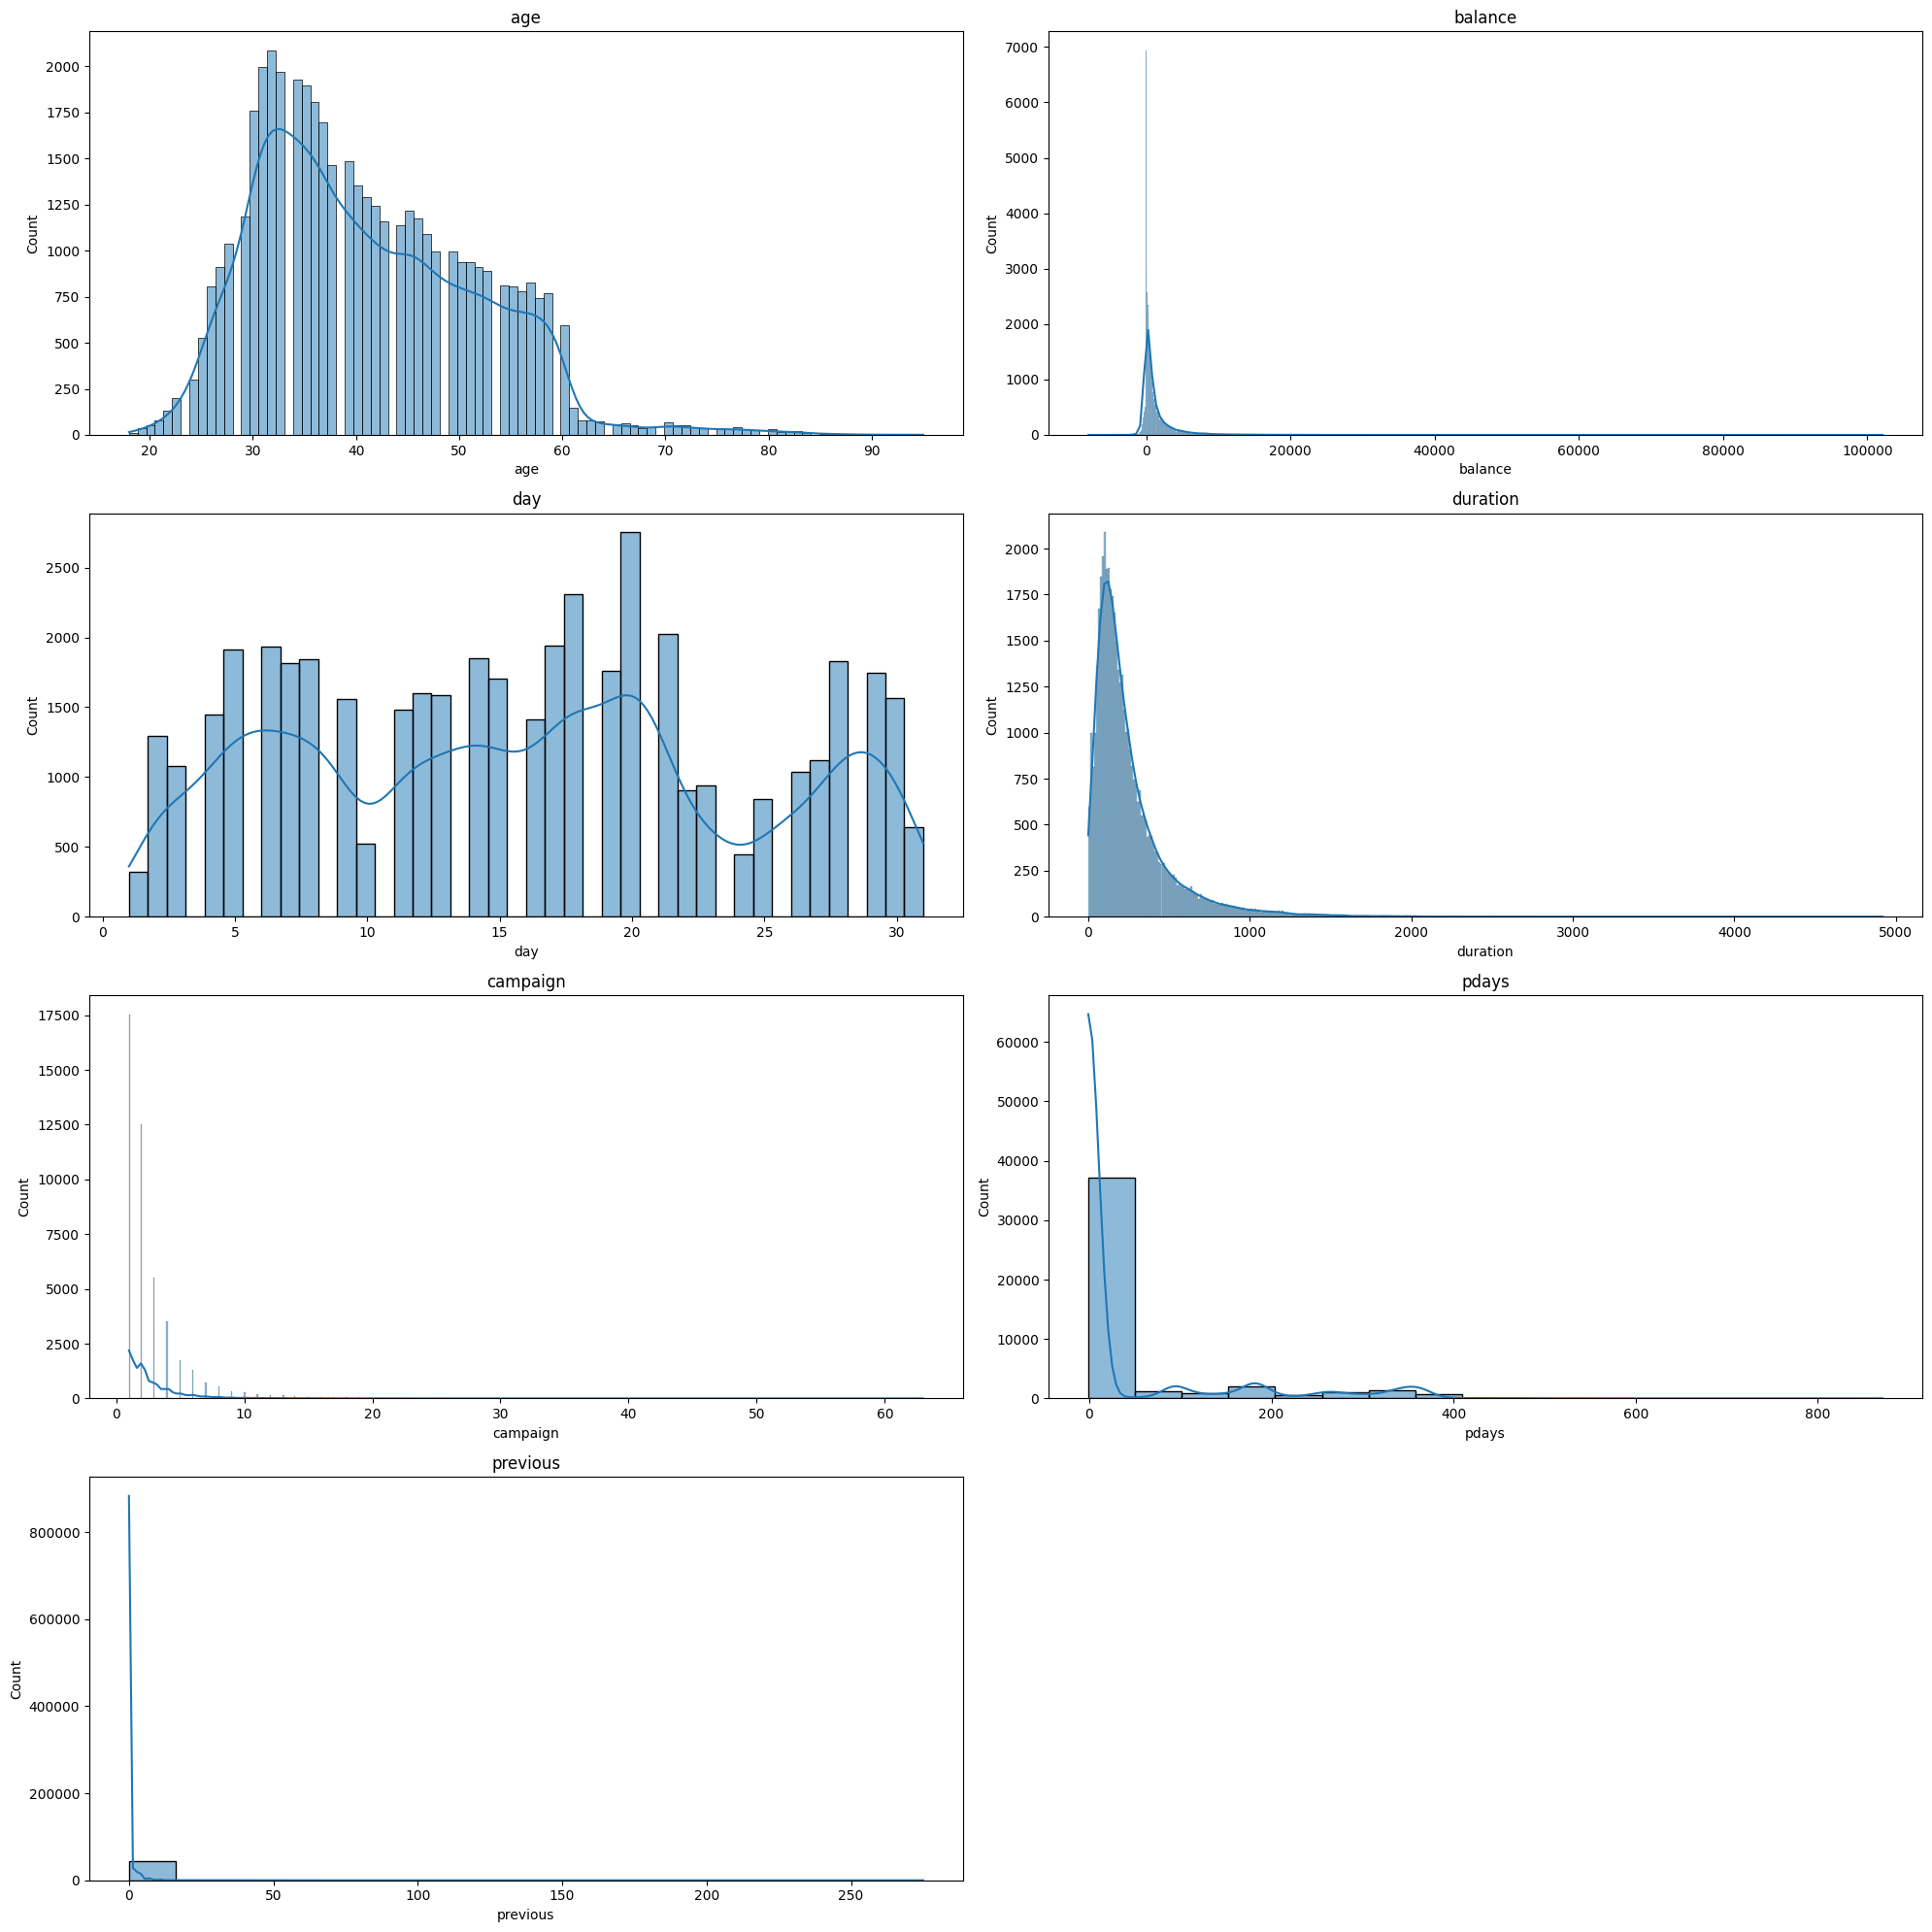

In [14]:
plt.figure(figsize = (20,20))
for i,col in enumerate(num_cols):
  plt.subplot(4,2,i+1)
  sns.histplot(df_bank[col].dropna(),kde = True)
  plt.title(col)
plt.tight_layout()

# INFERENCE
#-----------
# All have skewed distribution

##Correlation

In [15]:
# Creating correlation matrix
corr_mat = df_bank[num_cols].corr()
corr_mat

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288
balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674
day,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710
duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203
campaign,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855
pdays,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820
previous,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000


Text(0.5, 1.0, 'Correlation Heatmap')

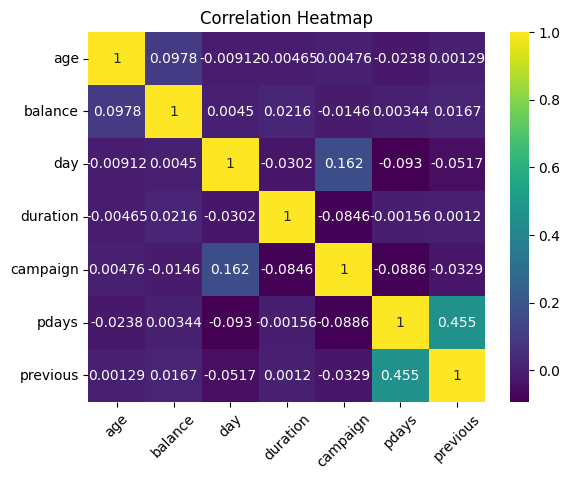

In [16]:
# plotting heatmap to visualize correlation matrix
sns.heatmap(corr_mat, annot = True, cmap = 'viridis', fmt ='.3g' )
plt.xticks(rotation = 45)
plt.title('Correlation Heatmap')

#Preprocessing

## Data Cleaning

###Missing Value Handling

In [17]:
##there are no missing value so no need to handle anything in this dataset

###Drop Unnecessary Columns

In [18]:
#dropping the column 'duration' since the duration is not known before a call is performed.
# Also, after the end of the call y is obviously known.

#dropping the column 'default' since the data is highly imbalanced
# dropping the column 'day' since day of month is unlikely to have any effect on the target variable
df_bank.drop(columns = ['duration', 'default', 'day'], inplace = True)
df_bank.head()

,age,job,marital,education,balance,housing,loan,contact,month,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,2143,yes,no,unknown,may,1,-1,0,unknown,no
1,44,technician,single,secondary,29,yes,no,unknown,may,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,2,yes,yes,unknown,may,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,1506,yes,no,unknown,may,1,-1,0,unknown,no
4,33,unknown,single,unknown,1,no,no,unknown,may,1,-1,0,unknown,no


In [19]:
num_cols = df_bank.select_dtypes(include =['int64' , 'float64']).columns


###Outlier analysis

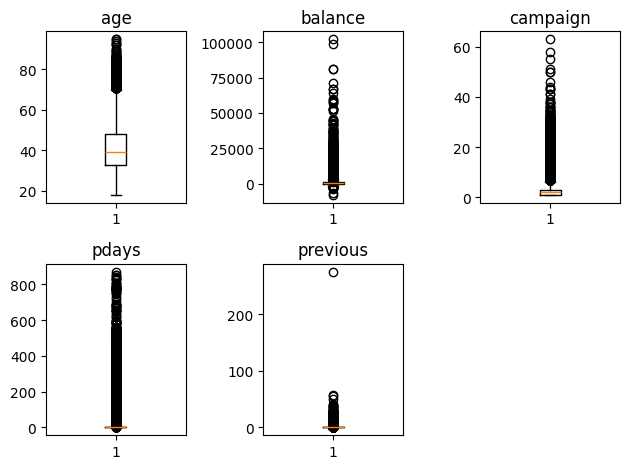

In [20]:
#plotting boxplot to visualize the outlier
for i,col in enumerate(num_cols):
  plt.subplot(2,3,i+1)
  plt.boxplot(df_bank[col])
  plt.title(col)
plt.tight_layout()
plt.show()

###Outlier handling

In [21]:
for col in num_cols:
  Q1 = df_bank[col].quantile(0.25)
  Q3 = df_bank[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5*IQR
  upper_bound = Q3 + 1.5*IQR
  print('Q1 :',Q1,'\n','Q3 :',Q3,'\n','IQR :',IQR,'\n','lower_bound :', lower_bound,'\n','upper_bound :',upper_bound)
  outliers = ((df_bank[col] < lower_bound) | (df_bank[col] > upper_bound))
  #before clipping

  print(f"Column '{col}': {outliers.sum()}")

Q1 : 33.0 
 Q3 : 48.0 
 IQR : 15.0 
 lower_bound : 10.5 
 upper_bound : 70.5
Column 'age': 487
Q1 : 72.0 
 Q3 : 1428.0 
 IQR : 1356.0 
 lower_bound : -1962.0 
 upper_bound : 3462.0
Column 'balance': 4729
Q1 : 1.0 
 Q3 : 3.0 
 IQR : 2.0 
 lower_bound : -2.0 
 upper_bound : 6.0
Column 'campaign': 3064
Q1 : -1.0 
 Q3 : -1.0 
 IQR : 0.0 
 lower_bound : -1.0 
 upper_bound : -1.0
Column 'pdays': 8257
Q1 : 0.0 
 Q3 : 0.0 
 IQR : 0.0 
 lower_bound : 0.0 
 upper_bound : 0.0
Column 'previous': 8257


In [22]:
#after clipping
for col in num_cols:
    df_bank[col] = df_bank[col].clip(lower_bound, upper_bound)

    # After clipping, verify if any outliers remain
    outliers = ((df_bank[col] < lower_bound) | (df_bank[col] > upper_bound))
    print(f"Column '{col}': {outliers.sum()}")

Column 'age': 0
Column 'balance': 0
Column 'campaign': 0
Column 'pdays': 0
Column 'previous': 0


###Duplicates handling

In [23]:
# before duplicate removal
df_bank.duplicated().sum()

np.int64(36466)

In [24]:
df_bank.drop_duplicates(inplace = True)

In [25]:
# after duplicate removal
df_bank.duplicated().sum()

np.int64(0)

## Data Transformation

###Encoding

In [26]:
# dataframe before encoding
df_bank.head()

,age,job,marital,education,balance,housing,loan,contact,month,campaign,pdays,previous,poutcome,y
0,0,management,married,tertiary,0,yes,no,unknown,may,0,0,0,unknown,no
1,0,technician,single,secondary,0,yes,no,unknown,may,0,0,0,unknown,no
2,0,entrepreneur,married,secondary,0,yes,yes,unknown,may,0,0,0,unknown,no
3,0,blue-collar,married,unknown,0,yes,no,unknown,may,0,0,0,unknown,no
4,0,unknown,single,unknown,0,no,no,unknown,may,0,0,0,unknown,no


In [27]:
# Encoding is done on non numeric columns
print(f'categorical columns:{cat_cols}')

categorical columns:Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')


In [28]:
# Here  column 'y' is the target  so label ecoding is used
# Also 'housing','loan' have binary output yes and no , therefore label encoding is used

In [29]:
label_enc = LabelEncoder()
label_cols = ['housing', 'loan', 'y']
for col in label_cols:
    df_bank[col] = label_enc.fit_transform(df_bank[col])


In [30]:
# For the rest of the  categorical columns we use one hot encoding because these categories have no order
# Columns to be One-hot encoded
one_hot_cols = ['job', 'marital', 'education','contact', 'month', 'poutcome']

# Create encoder
encoder = OneHotEncoder(sparse_output=False)

# Encode the selected columns
encoded_data = encoder.fit_transform(df_bank[one_hot_cols])

# Create a DataFrame with encoded columns
encoded_df = pd.DataFrame(encoded_data, columns = encoder.get_feature_names_out(one_hot_cols), index = df_bank.index)

# Remove original categorical columns
df_bank = df_bank.drop(columns=one_hot_cols)
# concat encoded columns to original dataframe
df_bank = pd.concat([df_bank, encoded_df], axis=1)

In [31]:
# Dataframe after encoding
df_bank.head()

,age,balance,housing,loan,campaign,pdays,previous,y,job_admin.,job_blue-collar,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,0,0,1,0,0,0,0,0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,0,1,0,0,0,0,0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0,0,1,1,0,0,0,0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0,0,1,0,0,0,0,0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0,0,0,0,0,0,0,0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


###Mutual information

In [32]:
# Our target column is 'y'.
# Since 'y' is a binary target variable, we use mutual_info_classif().
# Separate the dataset into features (X) and target (y).
X = df_bank.drop('y', axis=1)
y = df_bank['y']

# To seperate  discrete
discrete_features = [
    col not in ['age', 'balance', 'campaign', 'pdays', 'previous']
    for col in X.columns
]
# Mutual information of each column in 'X' w.r.t 'y'
mi = mutual_info_classif(X,y,discrete_features = discrete_features, random_state = 42)

#converting mi values into a dataframe to understand better
mi_df = pd.DataFrame({'Features': X.columns, 'mutual Information':mi})

# Display mi
mi_df

# Based on the Mutual Information scores, no features are removed.

,Features,mutual Information
0,age,0.002140
1,balance,0.000000
2,housing,0.004739
3,loan,0.011008
4,campaign,0.009782
5,pdays,0.000000
6,previous,0.000000
7,job_admin.,0.000044
8,job_blue-collar,0.000050
9,job_entrepreneur,0.001463


###Data splitting

In [33]:
#splitting into target and features
y = df_bank['y']
X = df_bank.drop('y', axis = 1)

#splitting into train-test
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    random_state = 42)


###Scaling

In [34]:
# Dataframe before scaling
df_bank.head()

,age,balance,housing,loan,campaign,pdays,previous,y,job_admin.,job_blue-collar,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,0,0,1,0,0,0,0,0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,0,1,0,0,0,0,0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0,0,1,1,0,0,0,0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0,0,1,0,0,0,0,0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0,0,0,0,0,0,0,0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [35]:
# Scale only continuos numeric values
print(num_cols)

scaler = MinMaxScaler()
df_bank[num_cols] = scaler.fit_transform(df_bank[num_cols])

Index(['age', 'balance', 'campaign', 'pdays', 'previous'], dtype='object')


In [36]:
# Dataframe after scaling
df_bank.head()

,age,balance,housing,loan,campaign,pdays,previous,y,job_admin.,job_blue-collar,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,0.0,0.0,1,0,0.0,0.0,0.0,0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,1,0,0.0,0.0,0.0,0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,1,1,0.0,0.0,0.0,0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,1,0,0.0,0.0,0.0,0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0,0,0.0,0.0,0.0,0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [37]:
#scaling after train - test split
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X = scaler.fit_transform(X)

#Model Building

##Models

### SVM

In [38]:
#building the model object
SVM_obj = SVC()
#training the model
SVM_obj.fit(X_train, y_train)
# predictions using the model
y_pred_SVM = SVM_obj.predict(X_test)

# evaluate the model performance
acc_SVM = accuracy_score(y_test, y_pred_SVM)
precision_score_SVM = precision_score(y_test, y_pred_SVM)
recall_score_SVM = recall_score(y_test, y_pred_SVM)
f1_score_SVM = f1_score(y_test, y_pred_SVM)


print("SVM Accuracy:", acc_SVM)
print("SVM Precision:", precision_score_SVM)
print("SVM Recall:", recall_score_SVM)
print("SVM F1 Score:", f1_score_SVM)



SVM Accuracy: 0.7095483133218983
SVM Precision: 0.6051282051282051
SVM Recall: 0.21493624772313297
SVM F1 Score: 0.3172043010752688


In [39]:
##Cross Validation

### k - fold cross validation
print("K- fold cross validation")
kf_obj = KFold(n_splits = 2, shuffle = True, random_state=29)
scores_kf = cross_val_score(SVC(), X, y, cv = kf_obj)
print("For SVM model")
print('Cross validation scores :', scores_kf)
print('mean of cv scores : ', scores_kf.mean())

#*********************************************************************
print("*******************************************************************")

### GridSearch cross validation
print("GridSearch cross validation")
## define the parameters you want to check
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [0.1, 0.01],
    'kernel': ['rbf', 'linear']
}

#building the model object
grid_search = GridSearchCV(estimator=SVC(),
                           param_grid=param_grid,
                           cv=2,
                           scoring='accuracy')

# Train
grid_search.fit(X, y)
# Print best parameters
print("best parameters are :", grid_search.best_params_)
print('best cross validation score : ', grid_search.best_score_)

#***********************************************************************
print("*******************************************************************")

###RandomSearch Cross Validation
print("Random Search cross validation")
# Define parameter distribution
param_dist = {
    'C': [0.1, 1, 10],
    'gamma': [1, 0.1, 0.01],
    'kernel': ['rbf', 'linear']
}

# Build RandomizedSearch object
random_search = RandomizedSearchCV(SVC(),
                                   param_distributions=param_dist,
                                   n_iter=2,        # tries 5 random combinations
                                   cv=2,
                                   scoring='accuracy',
                                   random_state=42)

# Train Random Search
random_search.fit(X, y)

# Print best parameters
print("Best Parameters are:", random_search.best_params_)
print("Best Cross Validation Score:", random_search.best_score_)

K- fold cross validation
For SVM model
Cross validation scores : [0.71369769 0.71500457]
mean of cv scores :  0.714351132469079
*******************************************************************
GridSearch cross validation
best parameters are : {'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}
best cross validation score :  0.6918230453906101
*******************************************************************
Random Search cross validation
Best Parameters are: {'kernel': 'rbf', 'gamma': 1, 'C': 0.1}
Best Cross Validation Score: 0.699256714192074


In [40]:
## Hyperparamter tuning

print("Hyperparameter tuning")
print("*******************************************************************")
print("Grid Search Cross Validation with Best Parameters")
# we build the model using the best parameters identified
SVM_model_HPT = SVC(C = 0.1,
                    gamma = 0.1,
                    kernel='rbf',
                    class_weight='balanced')

# training the model
SVM_model_HPT.fit(X_train, y_train)

# predictions using the model
y_pred_SVM_HPT = SVM_model_HPT.predict(X_test)

# evaluate the model performance
acc_SVM_HPT = accuracy_score(y_test, y_pred_SVM_HPT)
precision_SVM_HPT = precision_score(y_test, y_pred_SVM_HPT, zero_division=0)
recall_SVM_HPT = recall_score(y_test, y_pred_SVM_HPT, zero_division=0)
f1_SVM_HPT = f1_score(y_test, y_pred_SVM_HPT, zero_division=0)

print("Accuracy of SVM using Grid Search HPT:", acc_SVM_HPT)
print("Precision of SVM using Grid Search HPT:", precision_SVM_HPT)
print("Recall of SVM using Grid Search HPT:", recall_SVM_HPT)
print("F1 Score of SVM using Grid Search HPT:", f1_SVM_HPT)


#***************************************
print("*******************************************************************")
print("Random Search Cross Validation with Best Parameters")
# we build the model using the best parameters identified
SVM_model_RS = SVC(C = 0.1, # Best C from random search
                   gamma = 1, # Best gamma from random search
                   kernel='rbf',
                   class_weight='balanced')

# training the model
SVM_model_RS.fit(X_train, y_train)

# predictions using the model
y_pred_SVM_RS = SVM_model_RS.predict(X_test)

# evaluate the model performance
acc_SVM_RS = accuracy_score(y_test, y_pred_SVM_RS)
precision_SVM_RS = precision_score(y_test, y_pred_SVM_RS, zero_division=0)
recall_SVM_RS = recall_score(y_test, y_pred_SVM_RS, zero_division=0)
f1_SVM_RS = f1_score(y_test, y_pred_SVM_RS, zero_division=0)

print("Accuracy of SVM using Random Search HPT:", acc_SVM_RS)
print("Precision of SVM using Random Search HPT:", precision_SVM_RS)
print("Recall of SVM using Random Search HPT:", recall_SVM_RS)
print("F1 Score of SVM using Random Search HPT:", f1_SVM_RS)



Hyperparameter tuning
*******************************************************************
Grid Search Cross Validation with Best Parameters
Accuracy of SVM using Grid Search HPT: 0.6586620926243568
Precision of SVM using Grid Search HPT: 0.4136690647482014
Recall of SVM using Grid Search HPT: 0.20947176684881602
F1 Score of SVM using Grid Search HPT: 0.2781136638452237
*******************************************************************
Random Search Cross Validation with Best Parameters
Accuracy of SVM using Random Search HPT: 0.6861063464837049
Precision of SVM using Random Search HPT: 0.0
Recall of SVM using Random Search HPT: 0.0
F1 Score of SVM using Random Search HPT: 0.0


### Naive Bayes

In [41]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)
precision_score_nb = precision_score(y_test, y_pred_nb)
recall_score_nb = recall_score(y_test, y_pred_nb)
f1_score_nb = f1_score(y_test, y_pred_nb)

print('Accuracy of Naive Bayes',acc_nb)
print('Precision of Naive Bayes',precision_score_nb)
print('Recall of Naive Bayes',recall_score_nb)
print('F1 score of Naive Bayes',f1_score_nb)


Accuracy of Naive Bayes 0.6746712407089765
Precision of Naive Bayes 0.4781659388646288
Recall of Naive Bayes 0.3989071038251366
F1 score of Naive Bayes 0.43495531281032773


In [42]:
### Cross Validation

### k - fold cross validation
print("K- fold cross validation")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores_kf = cross_val_score(nb, X, y, cv = kf)
print("For Naive Bayes model")
print('Cross validation scores :', scores_kf)
print('mean of cv scores : ', scores_kf.mean())

#*********************************************************************
print("*******************************************************************")

### GridSearch cross validation
print("GridSearch cross validation")
## define the parameters you want to check
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5,
                      1e-4, 1e-3, 1e-2, 1e-1]
}
#building the model object
grid = GridSearchCV(GaussianNB(),
                    param_grid,
                    cv=5,
                    scoring='accuracy')

# Train
grid.fit(X, y)
# Print best parameters
print("best parameters are :", grid.best_params_)
print('best cross validation score : ', grid.best_score_)

#***********************************************************************
print("*******************************************************************")

###RandomSearch Cross Validation
print("Random Search cross validation")

# Define parameter distribution
param_dist = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5,
                      1e-4, 1e-3, 1e-2, 1e-1]
}


# Build RandomizedSearch object
random_search_nb = RandomizedSearchCV(GaussianNB(),
                                   param_distributions=param_dist,
                                   n_iter=5,        # tries 5 random combinations
                                   cv=5,
                                   scoring='accuracy',
                                   random_state=42)

# Train Random Search
random_search_nb.fit(X, y)

# Print best parameters
print("Best Parameters are:", random_search_nb.best_params_)
print("Best Cross Validation Score:", random_search_nb.best_score_)


K- fold cross validation
For Naive Bayes model
Cross validation scores : [0.67467124 0.67981704 0.70268725 0.68610635 0.67810177]
mean of cv scores :  0.6842767295597485
*******************************************************************
GridSearch cross validation
best parameters are : {'var_smoothing': 0.1}
best cross validation score :  0.3119496855345912
*******************************************************************
Random Search cross validation
Best Parameters are: {'var_smoothing': 0.1}
Best Cross Validation Score: 0.3119496855345912


In [43]:
## Hyperparamter tuning

print("Hyperparameter tuning")
print("*******************************************************************")
print("Grid Search Cross Validation with Best Parameters")
# we build the model using the best parameters identified
NB_model_HPT = GaussianNB(var_smoothing = 0.1)

# training the model
NB_model_HPT.fit(X_train, y_train)

# predictions using the model
y_pred_NB_HPT = NB_model_HPT.predict(X_test)

# evaluate the model performance
acc_NB_HPT = accuracy_score(y_test, y_pred_NB_HPT)
precision_NB_HPT = precision_score(y_test, y_pred_NB_HPT)
recall_NB_HPT = recall_score(y_test, y_pred_NB_HPT)
f1_NB_HPT = f1_score(y_test, y_pred_NB_HPT)

print("Accuracy of Naive Bayes using Grid Search HPT:", acc_NB_HPT)
print("Precision of Naive Bayes using Grid Search HPT:", precision_NB_HPT)
print("Recall of Naive Bayes using Grid Search HPT:", recall_NB_HPT)
print("F1 Score of Naive Bayes using Grid Search HPT:", f1_NB_HPT)

print("**************************************")
###RandomSearch Cross Validation
print("Random Search cross validation")
# we build the model using the best parameters identified
NB_model_RS = GaussianNB(var_smoothing = 0.1)

# training the model
NB_model_RS.fit(X_train, y_train)

# predictions using the model
y_pred_NB_RS = NB_model_RS.predict(X_test)

# evaluate the model performance
acc_NB_RS = accuracy_score(y_test, y_pred_NB_RS)
precision_NB_RS = precision_score(y_test, y_pred_NB_RS)
recall_NB_RS = recall_score(y_test, y_pred_NB_RS)
f1_NB_RS = f1_score(y_test, y_pred_NB_RS)

print("Accuracy of Naive Bayes using Random Search HPT:", acc_NB_RS)
print("Precision of Naive Bayes using Random Search HPT:", precision_NB_RS)
print("Recall of Naive Bayes using Random Search HPT:", recall_NB_RS)
print("F1 Score of Naive Bayes using Random Search HPT:", f1_NB_RS)

Hyperparameter tuning
*******************************************************************
Grid Search Cross Validation with Best Parameters
Accuracy of Naive Bayes using Grid Search HPT: 0.6746712407089765
Precision of Naive Bayes using Grid Search HPT: 0.47757847533632286
Recall of Naive Bayes using Grid Search HPT: 0.3879781420765027
F1 Score of Naive Bayes using Grid Search HPT: 0.42814070351758793
**************************************
Random Search cross validation
Accuracy of Naive Bayes using Random Search HPT: 0.6746712407089765
Precision of Naive Bayes using Random Search HPT: 0.47757847533632286
Recall of Naive Bayes using Random Search HPT: 0.3879781420765027
F1 Score of Naive Bayes using Random Search HPT: 0.42814070351758793


###Comparison between SVM and Naive Bayes

In [44]:
classification_results = pd.DataFrame({

    "Model":[
        "SVM",
        "Naive Bayes"
    ],

    "Accuracy":[
        acc_SVM,
        acc_nb
    ],

    "Precision":[
        precision_score_SVM,
        precision_score_nb
    ],

    "Recall":[
        recall_score_SVM,
        recall_score_nb
    ],

    "F1 Score":[
        f1_score_SVM,
        f1_score_nb
    ]
})

classification_results

,Model,Accuracy,Precision,Recall,F1 Score
0,SVM,0.709548,0.605128,0.214936,0.317204
1,Naive Bayes,0.674671,0.478166,0.398907,0.434955


In [45]:

# best performing model

best_class = classification_results.loc[
    classification_results['Accuracy'].idxmax()
]

print(best_class)

Model             SVM
Accuracy     0.709548
Precision    0.605128
Recall       0.214936
F1 Score     0.317204
Name: 0, dtype: object


In [46]:
# SVM is a better model

#Ensemble
## Bagging
# Build Bagging with SVM
bagging_svm = BaggingClassifier(estimator=SVC(class_weight='balanced'),
                                n_estimators=10,
                                random_state=42)

# Train
bagging_svm.fit(X_train, y_train)

# Predict
y_pred_bagging = bagging_svm.predict(X_test)

# Evaluate
print("========== Bagging SVM ==========")
print("Accuracy:", accuracy_score(y_test, y_pred_bagging))
print("Precision:", precision_score(y_test, y_pred_bagging, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_bagging, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_bagging, zero_division=0))


print("******************************")

#Boosting
print("Boosting")
# Build AdaBoost with SVM
adaboost_svm = AdaBoostClassifier(estimator=SVC(probability=True,
                                                 kernel='rbf',
                                                 class_weight='balanced'),
                                   n_estimators=10,
                                   random_state=42)

# Train
adaboost_svm.fit(X_train, y_train)

# Predict
y_pred_adaboost = adaboost_svm.predict(X_test)

# Evaluate
print("========== AdaBoost SVM ==========")
print("Accuracy:", accuracy_score(y_test, y_pred_adaboost))
print("Precision:", precision_score(y_test, y_pred_adaboost, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_adaboost, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_adaboost, zero_division=0))



========== Bagging SVM ==========
Accuracy: 0.6432246998284734
Precision: 0.44798890429958393
Recall: 0.5883424408014571
F1 Score: 0.5086614173228347
******************************
Boosting
========== AdaBoost SVM ==========
Accuracy: 0.6861063464837049
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


###Decision Tree Model Building

In [47]:
# building model object
dT_model = DecisionTreeClassifier()

# Training the model
dT_model.fit(X_train, y_train)

# Predicting using the model
y_pred_dT = dT_model.predict(X_test)

# Evaluate model performance
acc_dT = accuracy_score(y_test, y_pred_dT)
precision_score_dT = precision_score(y_test, y_pred_dT)
recall_score_dT = recall_score(y_test, y_pred_dT)
f1_score_dT = f1_score(y_test, y_pred_dT)



print('Accuracy of Decision Tree model',acc_dT)
print('Precision of Decision Tree model',precision_score_dT)
print('Recall of Decision Tree model',recall_score_dT)
print('F1 score of Decision Tree model',f1_score_dT)



Accuracy of Decision Tree model 0.5105774728416238
Precision of Decision Tree model 0.1936127744510978
Recall of Decision Tree model 0.1766848816029144
F1 score of Decision Tree model 0.18476190476190477


In [48]:
# Cross validation

# StratifiedKFold

# Since dataset is imbalanced , we have to use StratifiedKFold
# Since datset is imbalanced ,  we can't relay on accuracy alone
skf_obj = StratifiedKFold(n_splits = 5 , shuffle = True , random_state = 27)
scores = cross_val_score(DecisionTreeClassifier() , X_train ,y_train , cv = skf_obj, scoring ='f1')
print("For Decision Tree model")
print('StratifiedKFold cross validation scores : ', scores)
print('Mean of cv scores : ', scores.mean())
print("\n\n\n")


# GridSearchCV

# Since datset is imbalanced ,  we can't relay on accuracy alone
para_grid = {'criterion' : ['gini','entropy'], 'max_depth' : [2,3,4,5,6,8,10] , 'min_samples_split': [2,4,6,8]}

grid = GridSearchCV(DecisionTreeClassifier(random_state = 42), para_grid , cv = 5, scoring = 'f1')
grid.fit(X_train,y_train)
print("For Decision Tree model")
print("Best parameters : ",grid.best_params_)
print("Best cross validation score : ",grid.best_score_)

# Hyper parameter Tuning

# we build the model using the best parameters identified
best_dT_grid = grid.best_estimator_
# Train the model
best_dT_grid.fit(X_train,y_train)
# make prediction using the model
y_pred_dT_grid = best_dT_grid.predict(X_test)
# evaluate the model performance
print("Accuracy :", accuracy_score(y_test, y_pred_dT_grid))
print("Precision :", precision_score(y_test, y_pred_dT_grid))
print("Recall :", recall_score(y_test, y_pred_dT_grid))
print("F1 Score :", f1_score(y_test, y_pred_dT_grid))
print("\n\n\n")



# Random search CV

# Since datset is imbalanced ,  we can't relay on accuracy alone
grid_random = RandomizedSearchCV(DecisionTreeClassifier(random_state = 42),  param_distributions = para_grid , cv = 5, scoring = 'f1')
grid_random.fit(X_train,y_train)
print("For Decision Tree model")
print("Best parameters : ",grid_random.best_params_)
print("Best cross validation score : ",grid_random.best_score_)

# Hyper parameter Tuning

# we build the model using the best parameters identified
best_dT_random = grid_random.best_estimator_
# Train the model
best_dT_random.fit(X_train,y_train)
# make prediction using the model
y_pred_dT_random = best_dT_random.predict(X_test)
# evaluate the model performance
print("Accuracy :", accuracy_score(y_test, y_pred_dT_random))
print("Precision :", precision_score(y_test, y_pred_dT_random))
print("Recall :", recall_score(y_test, y_pred_dT_random))
print("F1 Score :", f1_score(y_test, y_pred_dT_random))


For Decision Tree model
StratifiedKFold cross validation scores :  [0.20628931 0.20906801 0.23144654 0.22166874 0.22141998]
Mean of cv scores :  0.21797851545629382




For Decision Tree model
Best parameters :  {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Best cross validation score :  0.30484239905300997
Accuracy : 0.7141223556317896
Precision : 0.6560509554140127
Recall : 0.18761384335154827
F1 Score : 0.29178470254957506




For Decision Tree model
Best parameters :  {'min_samples_split': 6, 'max_depth': 3, 'criterion': 'gini'}
Best cross validation score :  0.30484239905300997
Accuracy : 0.7141223556317896
Precision : 0.6560509554140127
Recall : 0.18761384335154827
F1 Score : 0.29178470254957506


### Random Forest Model Building


In [49]:
# building model object
rf_model = RandomForestClassifier()

# Training the model
rf_model.fit(X_train, y_train)

# Predicting using the model
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model performance
acc_rf = accuracy_score(y_test, y_pred_rf)
precision_score_rf = precision_score(y_test, y_pred_rf)
recall_score_rf = recall_score(y_test, y_pred_rf)
f1_score_rf = f1_score(y_test, y_pred_rf)



print('Accuracy of Random Forest model',acc_rf)
print('Precision of Random Forest model',precision_score_rf)
print('Recall of Random Forest model',recall_score_rf)
print('F1 score of Random Forest model',f1_score_rf)



Accuracy of Random Forest model 0.5494568324757004
Precision of Random Forest model 0.21204819277108433
Recall of Random Forest model 0.16029143897996356
F1 score of Random Forest model 0.1825726141078838


In [50]:
# Cross validation

# StratifiedKFold

# Since dataset is imbalanced , we have to use StratifiedKFold
# Since datset is imbalanced ,  we can't rely on accuracy alone
skf_obj = StratifiedKFold(n_splits = 5 , shuffle = True , random_state = 27)
scores = cross_val_score(RandomForestClassifier() , X_train ,y_train , cv = skf_obj, scoring ='f1')
print("For Random Forest model")
print('StratifiedKFold cross validation scores : ', scores)
print('Mean of cv scores : ', scores.mean())
print("\n\n\n")


# GridSearchCV

# Since datset is imbalanced ,  we can't relay on accuracy alone
para_grid = {'n_estimators' : [50, 100, 200] , 'criterion' : ['gini','entropy'], 'max_depth' : [5, 10, 20] , 'min_samples_split': [2, 5, 10]}

grid = GridSearchCV(RandomForestClassifier(random_state = 42), para_grid , cv = skf_obj, scoring = 'f1')
grid.fit(X_train,y_train)
print("For Random Forest model")
print("Best parameters : ",grid.best_params_)
print("Best cross validation score : ",grid.best_score_)

# Hyperparameter Tuning

# we build the model using the best parameters identified
best_rf_grid = grid.best_estimator_
# Train the model
best_rf_grid.fit(X_train,y_train)
# make prediction using the model
y_pred_rf_grid = best_rf_grid.predict(X_test)
# evaluate the model performance
print("Accuracy :", accuracy_score(y_test, y_pred_rf_grid))
print("Precision :", precision_score(y_test, y_pred_rf_grid))
print("Recall :", recall_score(y_test, y_pred_rf_grid))
print("F1 Score :", f1_score(y_test, y_pred_rf_grid))
print("\n\n\n")



# Random search CV

# Since datset is imbalanced ,  we can't relay on accuracy alone
grid_random = RandomizedSearchCV(RandomForestClassifier(random_state = 42),  param_distributions = para_grid , cv = skf_obj, scoring = 'f1', n_iter = 10)
grid_random.fit(X_train,y_train)
print("For Random Forest model")
print("Best parameters : ",grid_random.best_params_)
print("Best cross validation score : ",grid_random.best_score_)


# Hyperparameter Tuning

# we build the model using the best parameters identified
best_rf_random = grid_random.best_estimator_
# Train the model
best_rf_random.fit(X_train,y_train)
# make prediction using the model
y_pred_rf_random = best_rf_random.predict(X_test)
# evaluate the model performance
print("Accuracy :", accuracy_score(y_test, y_pred_rf_random))
print("Precision :", precision_score(y_test, y_pred_rf_random))
print("Recall :", recall_score(y_test, y_pred_rf_random))
print("F1 Score :", f1_score(y_test, y_pred_rf_random))


For Random Forest model
StratifiedKFold cross validation scores :  [0.19428571 0.20576132 0.20542083 0.2070922  0.230563  ]
Mean of cv scores :  0.20862461196202225




For Random Forest model
Best parameters :  {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}
Best cross validation score :  0.26743726509306437
Accuracy : 0.7061177815894797
Precision : 0.6470588235294118
Recall : 0.14025500910746813
F1 Score : 0.23053892215568864




For Random Forest model
Best parameters :  {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 10, 'criterion': 'gini'}
Best cross validation score :  0.26411956887877996
Accuracy : 0.707833047455689
Precision : 0.6439393939393939
Recall : 0.15482695810564662
F1 Score : 0.24963289280469897


###Comparing Decision Tree and Random Forest

In [51]:
classification_results = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        acc_dT,
        acc_rf
    ],

    "Precision":[
        precision_score_dT,
        precision_score_rf
    ],

    "Recall":[
        recall_score_dT,
        recall_score_rf
    ],

    "F1 Score":[
        f1_score_dT,
        f1_score_rf
    ]
})

classification_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.510577,0.193613,0.176685,0.184762
1,Random Forest,0.549457,0.212048,0.160291,0.182573


In [52]:
# Ensemble model

# Bagging model


# build the model object
bagging_model = BaggingClassifier(estimator = DecisionTreeClassifier(), n_estimators = 5 , max_samples = .6, bootstrap = True, random_state = 33 )
# Train the model
bagging_model.fit(X_train,y_train)
# make prediction using the model
y_pred_bg = bagging_model.predict(X_test)
# evaluate the model performance
print("For Decision tree bagging model : \n")
print("Accuracy :", accuracy_score(y_test, y_pred_bg))
print("Precision :", precision_score(y_test, y_pred_bg))
print("Recall :", recall_score(y_test, y_pred_bg))
print("F1 Score :", f1_score(y_test, y_pred_bg))
print("\n")



# Boosting model


# build the model object
ada_boost_model = AdaBoostClassifier(estimator = DecisionTreeClassifier(max_depth = 1), n_estimators = 20, learning_rate = 1)
# Train the model
ada_boost_model.fit(X_train,y_train)
# make prediction using the model
y_pred_ada_bo = ada_boost_model.predict(X_test)
# evaluate the model performance
print("For Decision tree Boosting model :\n")
print("Accuracy :", accuracy_score(y_test, y_pred_ada_bo))
print("Precision :", precision_score(y_test, y_pred_ada_bo))
print("Recall :", recall_score(y_test, y_pred_ada_bo))
print("F1 Score :", f1_score(y_test, y_pred_ada_bo))


For Decision tree bagging model : 

Accuracy : 0.5717552887364208
Precision : 0.26851851851851855
Recall : 0.21129326047358835
F1 Score : 0.23649337410805302


For Decision tree Boosting model :

Accuracy : 0.7169811320754716
Precision : 0.66875
Recall : 0.19489981785063754
F1 Score : 0.3018335684062059


### Logistic Regression

In [53]:
# Build model
Log_Reg = LogisticRegression()

# Train model
Log_Reg.fit(X_train, y_train)

# Make predicitons using model
y_pred_LR = Log_Reg.predict(X_test)

# Evaluation
accuracy_LR = accuracy_score(y_test,y_pred_LR)
recall_LR = recall_score(y_test,y_pred_LR)
prec_LR = precision_score(y_test,y_pred_LR)
f1_score_LR = f1_score(y_test, y_pred_LR)
print('Accuracy: ',accuracy_LR)
print('Recall: ',recall_LR)
print('Precision: ',prec_LR)
print("F1 Score:",f1_score_LR )

Accuracy:  0.7089765580331618
Recall:  0.2185792349726776
Precision:  0.6
F1 Score: 0.3204272363150868


In [54]:
# Cross Validation - K Fold
# -------------------------------------------------------------------------
print("K-Fold Cross Validation")

kf_obj = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(Log_Reg, X, y, cv=kf_obj)

print("For Logistic Regression Model")
print("cross validation scores: ",scores)
print("mean of cv scores: ", np.mean(scores))


# -------------------------------------------------------------------------

# Grid Search

print("\nGrid Search")

# Parameters for Logistic Regression
parameter_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [100, 200, 500]
}

grid = GridSearchCV( estimator=Log_Reg, param_grid=parameter_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Score:", grid.best_score_)

#  Logistic regression Model based on Cross val

Log_Reg_gs = LogisticRegression(C=0.01,max_iter=100,penalty='l2',solver='liblinear')

# Train model
Log_Reg_gs.fit(X_train, y_train)

# Make predictions
y_pred_LR_gs = Log_Reg_gs.predict(X_test)

# Evaluate
accuracy_LR_gs = accuracy_score(y_test, y_pred_LR_gs)
print("Accuracy:", accuracy_LR_gs)

# -------------------------------------------------------------------------

# Random Search

print("\nRandom Search")

random_search = RandomizedSearchCV( estimator=Log_Reg, param_distributions=parameter_grid, n_iter=10, cv=5, scoring='accuracy', random_state=42, n_jobs=-1)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Cross Validation Score:", random_search.best_score_)


# Model Building using random search best parameters

Log_Reg_rs = LogisticRegression(solver='saga', penalty='l1', max_iter=100, C=0.1)

# Train model
Log_Reg_rs.fit(X_train, y_train)

# Make predictions
y_pred_rs = Log_Reg_rs.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rs))

K-Fold Cross Validation
For Logistic Regression Model
cross validation scores:  [0.70897656 0.70897656 0.7238422  0.72670097 0.71469411]
mean of cv scores:  0.7166380789022299

Grid Search
Best Parameters: {'C': 0.01, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best Cross Validation Score: 0.7224138670478913
Accuracy: 0.7084048027444254

Random Search
Best Parameters: {'solver': 'liblinear', 'penalty': 'l1', 'max_iter': 100, 'C': 0.01}
Best Cross Validation Score: 0.7224138670478913
Accuracy: 0.7089765580331618


In [55]:
# Ensemble
#----------------------------------------------------------------------
# Bagging
#---------------------------------------------------------------------------
bag_lr = BaggingClassifier(estimator = Log_Reg, n_estimators = 50, max_samples = 0.8, max_features=1.0,bootstrap=True,random_state=42)

# Train
bag_lr.fit(X_train, y_train)

# Predict
y_pred = bag_lr.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.7084048027444254
Precision: 0.5979899497487438
Recall: 0.2167577413479053
F1 Score: 0.3181818181818182


In [56]:
# Boosting
#---------------------------------------------------------------------

# Build model
adaboost_obj = AdaBoostClassifier( estimator= Log_Reg , n_estimators= 20, learning_rate= 1)

# Train model
adaboost_obj.fit(X_train, y_train)

# make predicitons using model
y_pred_aboost = adaboost_obj.predict(X_test)

#evaluate
accuracy_aboost = accuracy_score(y_test,y_pred_aboost)
print('Accuracy: ',accuracy_aboost)

Accuracy:  0.7061177815894797


### KNN

In [57]:
# build model
knn_obj = KNeighborsClassifier(n_neighbors= 8)

# Train model
knn_obj.fit(X_train, y_train)

# make predicitons using model
y_pred_kn = knn_obj.predict(X_test)

#evaluate
accuracy_kn = accuracy_score(y_test,y_pred_kn)
recall_kn = recall_score(y_test,y_pred_kn)
prec_kn = precision_score(y_test,y_pred_kn)
f1_score_kn = f1_score(y_test, y_pred_kn)

print('Accuracy: ',accuracy_kn)
print('Recall: ',recall_kn)
print('Precision: ',prec_kn)
print("F1 Score:",f1_score_kn)

Accuracy:  0.6706689536878216
Recall:  0.122040072859745
Precision:  0.4161490683229814
F1 Score: 0.18873239436619718


In [58]:
# Cross Validation
#------------------------------------------------------------------------
# K-Fold

print("K-Fold Cross Validation")

kf_obj = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(knn_obj, X, y, cv=kf_obj)

print("For KNN Model")
print("cross validation scores: ",scores)
print("mean of cv scores: ", np.mean(scores))


# -------------------------------------------------------------------------
# Grid Search

print("\nGrid Search")

# Parameters for KNN
parameter_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]
}

grid = GridSearchCV(
    estimator=knn_obj,
    param_grid=parameter_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Score:", grid.best_score_)

# KNN Model based on Grid Search

knn_gs = KNeighborsClassifier(
    n_neighbors=11,
    weights='uniform',
    metric='euclidean'
)

# Train model
knn_gs.fit(X_train, y_train)

# Make predictions
y_pred_knn_gs = knn_gs.predict(X_test)

# Evaluate
accuracy_knn_gs = accuracy_score(y_test, y_pred_knn_gs)
print("Accuracy of GridSearch CV Model :", accuracy_knn_gs)

# -------------------------------------------------------------------------
# Random Search

print("\nRandom Search")

random_search = RandomizedSearchCV( estimator=knn_obj, param_distributions = parameter_grid, n_iter=20, cv=5, scoring='accuracy', random_state=42, n_jobs=-1)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Cross Validation Score:", random_search.best_score_)

# Model building using random search best parameters

knn_rs = KNeighborsClassifier(n_neighbors=11, weights='uniform', metric='manhattan', p=1)

# Train model
knn_rs.fit(X_train, y_train)

# Make predictions
y_pred_knn_rs = knn_gs.predict(X_test)

# Evaluate
accuracy_knn_rs = accuracy_score(y_test, y_pred_knn_rs)
print("Accuracy of Random Search CV Model:", accuracy_knn_rs)

K-Fold Cross Validation
For KNN Model
cross validation scores:  [0.67352773 0.68439108 0.69125214 0.68839337 0.68953688]
mean of cv scores:  0.6854202401372212

Grid Search
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 11, 'p': 1, 'weights': 'uniform'}
Best Cross Validation Score: 0.6925376289186154
Accuracy of GridSearch CV Model : 0.6655231560891939

Random Search
Best Parameters: {'weights': 'uniform', 'p': 1, 'n_neighbors': 11, 'metric': 'manhattan'}
Best Cross Validation Score: 0.6925376289186154
Accuracy of Random Search CV Model: 0.6655231560891939


# Deep Learning

### ANN

#### Model 1

In [60]:
# Model Building
# Model object
model_1 = Sequential()

# Hidden Layer
model_1.add(Dense(units = 32 , activation = 'relu'))

# Output layer
# Here output is binary classification so we use sigmoid activation function
model_1.add(Dense(units = 1, activation ='sigmoid'))


# Model Training
model_1.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy',Precision(),Recall()])
history_model_1 = model_1.fit(X_train, y_train, epochs = 100)



# Evaluate the model
loss, accuracy, precision, recall = model_1.evaluate(X_test, y_test)


# Predict using model1
y_pred_model_1 = model_1.predict(X_test)

print(y_pred_model_1)

Epoch 1/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6311 - loss: 0.6582 - precision: 0.3698 - recall: 0.3412
Epoch 2/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7196 - loss: 0.5608 - precision: 0.5750 - recall: 0.2191
Epoch 3/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7210 - loss: 0.5515 - precision: 0.5717 - recall: 0.2470
Epoch 4/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7236 - loss: 0.5460 - precision: 0.5803 - recall: 0.2552
Epoch 5/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7243 - loss: 0.5423 - precision: 0.5819 - recall: 0.2595
Epoch 6/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7281 - loss: 0.5385 - precision: 0.5941 - recall: 0.2715
Epoch 7/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7300 - loss: 0.5360 - precision: 0.6048 - recall: 0.2662
Epoch 8/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7311 - loss: 0.5337 - precision: 0.6029 - recall: 0.2816
Epoch 9/

In [61]:
# Threshold is 0.5
y_pred_model_1[y_pred_model_1 > 0.5] = 1
y_pred_model_1[y_pred_model_1 <= 0.5] = 0
y_pred_model_1


array([[0.],
       [0.],
       [1.],
       ...,
       [1.],
       [0.],
       [1.]], dtype=float32)

In [62]:
# Evaluating the model with test data
acc_model_1 = accuracy_score(y_test,y_pred_model_1)
precision_model_1 = precision_score(y_test,y_pred_model_1)
recall_model_1 = recall_score(y_test, y_pred_model_1)
f1_score_model_1 = f1_score(y_test, y_pred_model_1)


print(" Accuracy of the ANN model 1\t\t: ", acc_model_1)
print(" Precision of the ANN model 1\t \t: ", precision_model_1)
print(" Recall of the ANN model 1 \t\t: ", recall_model_1)
print(" F1 score of the ANN model 1 \t\t: ", f1_score_model_1)

 Accuracy of the ANN model 1		:  0.6477987421383647
 Precision of the ANN model 1	 	:  0.4188861985472155
 Recall of the ANN model 1 		:  0.3151183970856102
 F1 score of the ANN model 1 		:  0.3596673596673597


In [63]:
# INFERENCE
#--------------------
# Among the three ANN models implemented, Model 1 achieved the best performance with the highest accuracy (64.6%) and F1 score (0.316).
# Increasing the model complexity in Model 2 and Model 3 did not improve performance,
# indicating that the dataset does not require deeper architectures and that simpler models generalize better.

# Comparing all the models

In [64]:
classification_results = pd.DataFrame({

    "Model":[
        "SVM",
        "Naive Bayes",
        "Decision Tree",
        "Random Forest",
        "Bagging SVM",
        "Boosting SVM",
        "Decision Tree Bagging",
        "Decision Tree Boosting",
        "Logistic Regression",
        "Bagging Logistic Regression",
        "Boosting Logistic Regression",
        "KNN",
        "KNN GridSearch",
        "KNN RandomSearch",
        "ANN Model 1"
    ],

    "Accuracy":[
        acc_SVM,
        acc_nb,
        acc_dT,
        acc_rf,
        accuracy_score(y_test, y_pred_bagging),
        accuracy_score(y_test, y_pred_adaboost),
        accuracy_score(y_test, y_pred_bg),
        accuracy_score(y_test, y_pred_ada_bo),
        accuracy_LR,
        accuracy_score(y_test, y_pred),
        accuracy_aboost,
        accuracy_kn,
        accuracy_knn_gs,
        accuracy_knn_rs,
        acc_model_1
    ],

    "Precision":[
        precision_score_SVM,
        precision_score_nb,
        precision_score_dT,
        precision_score_rf,
        precision_score(y_test, y_pred_bagging, zero_division=0),
        precision_score(y_test, y_pred_adaboost, zero_division=0),
        precision_score(y_test, y_pred_bg, zero_division=0),
        precision_score(y_test, y_pred_ada_bo, zero_division=0),
        prec_LR,
        precision_score(y_test, y_pred, zero_division=0),
        precision_score(y_test, y_pred_aboost, zero_division=0),
        prec_kn,
        precision_score(y_test, y_pred_knn_gs, zero_division=0),
        precision_score(y_test, y_pred_knn_rs, zero_division=0),
        precision_model_1
    ],

    "Recall":[
        recall_score_SVM,
        recall_score_nb,
        recall_score_dT,
        recall_score_rf,
        recall_score(y_test, y_pred_bagging, zero_division=0),
        recall_score(y_test, y_pred_adaboost, zero_division=0),
        recall_score(y_test, y_pred_bg, zero_division=0),
        recall_score(y_test, y_pred_ada_bo, zero_division=0),
        recall_LR,
        recall_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred_aboost, zero_division=0),
        recall_kn,
        recall_score(y_test, y_pred_knn_gs, zero_division=0),
        recall_score(y_test, y_pred_knn_rs, zero_division=0),
        recall_model_1
    ],

    "F1 Score":[
        f1_score_SVM,
        f1_score_nb,
        f1_score_dT,
        f1_score_rf,
        f1_score(y_test, y_pred_bagging, zero_division=0),
        f1_score(y_test, y_pred_adaboost, zero_division=0),
        f1_score(y_test, y_pred_bg, zero_division=0),
        f1_score(y_test, y_pred_ada_bo, zero_division=0),
        f1_score_LR,
        f1_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred_aboost, zero_division=0),
        f1_score_kn,
        f1_score(y_test, y_pred_knn_gs, zero_division=0),
        f1_score(y_test, y_pred_knn_rs, zero_division=0),
        f1_score_model_1
    ]
})

classification_results


,Model,Accuracy,Precision,Recall,F1 Score
0,SVM,0.709548,0.605128,0.214936,0.317204
1,Naive Bayes,0.674671,0.478166,0.398907,0.434955
2,Decision Tree,0.510577,0.193613,0.176685,0.184762
3,Random Forest,0.549457,0.212048,0.160291,0.182573
4,Bagging SVM,0.643225,0.447989,0.588342,0.508661
5,Boosting SVM,0.686106,0.000000,0.000000,0.000000
6,Decision Tree Bagging,0.571755,0.268519,0.211293,0.236493
7,Decision Tree Boosting,0.716981,0.668750,0.194900,0.301834
8,Logistic Regression,0.708977,0.600000,0.218579,0.320427
9,Bagging Logistic Regression,0.708405,0.597990,0.216758,0.318182


## The best model

In [65]:
# Best model by Accuracy
print("Best Model by Accuracy:")
print(classification_results.loc[
    classification_results['Accuracy'].idxmax()
])

print("\nBest Model by F1 Score:")
print(classification_results.loc[
    classification_results['F1 Score'].idxmax()
])

print("\nBest Model by Recall:")
print(classification_results.loc[
    classification_results['Recall'].idxmax()
])


# Dataset is imbalanced so F1 Score and
# Recall are more reliable metrics than Accuracy

Best Model by Accuracy:
Model        Decision Tree Boosting
Accuracy                   0.716981
Precision                   0.66875
Recall                       0.1949
F1 Score                   0.301834
Name: 7, dtype: object

Best Model by F1 Score:
Model        Bagging SVM
Accuracy        0.643225
Precision       0.447989
Recall          0.588342
F1 Score        0.508661
Name: 4, dtype: object

Best Model by Recall:
Model        Bagging SVM
Accuracy        0.643225
Precision       0.447989
Recall          0.588342
F1 Score        0.508661
Name: 4, dtype: object


## Export the best model

In [76]:
import pickle
import os

best_model = bagging_svm

model_path = '/content/Bank_management_model/models/best_model.pkl'



with open(model_path, 'wb') as file:
    pickle.dump(best_model, file)
